## Cross validation

On part d'une image de taille M1xM2 que l'on resample en taille N1xN2. Lors d'un vrai rééchantillonage le facteur r de rééchantilloange doit vérifier N1=qM1 et N2=qM2. Lorqu'on a des faux positifs, la corrélation n'apparait que selon un axe et on peut donc ainsi l'éliminer. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def CrossVal(NFA_rows, NFA_cols, beta=0.005):
    """
    beta : relative tolerance
    Hypothèse :  q1/N1 ≈ q2/N2 à ±β près

    Return : NFA valide, significatif si proche de 0
    """
    N1,N2=NFA_rows.shape[0], NFA_cols.shape[0]
    ratios_rows = np.arange(N1) / (N1 - 1)
    ratios_cols = np.arange(N2) / (N2 - 1)
    NFA_valid = np.zeros(N1, dtype=np.float32)


    for d1 in range(N1):
        ratio_d1 = ratios_rows[d1]
        mask = np.abs(ratios_cols - ratio_d1) < beta
        if np.any(mask):
            bestNFA2 = np.min(NFA_cols[mask])
        else:
            bestNFA2 = np.max(NFA_cols)
        NFA_valid[d1]=max(NFA_rows[d1], bestNFA2)

    return NFA_valid

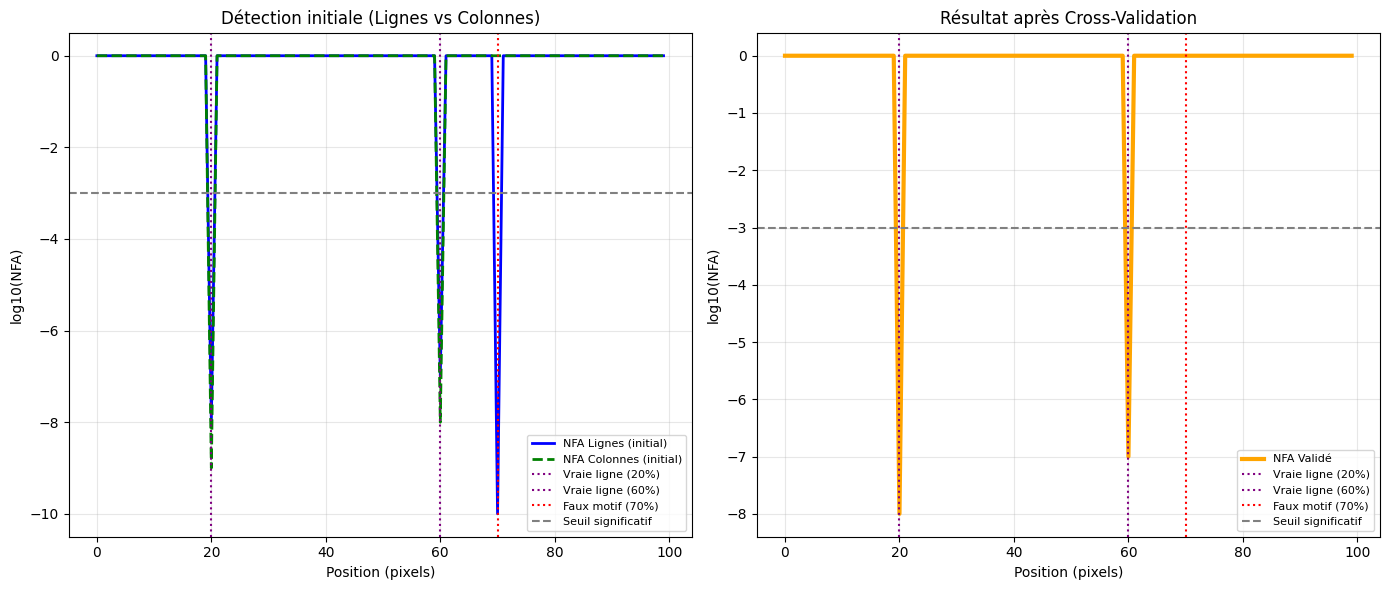

=== Résultats ===
Vraie ligne à 20% : NFA_valid = 1.00e-08 (log10 = -8.00) → VALIDÉ
Vraie ligne à 60% : NFA_valid = 1.00e-07 (log10 = -7.00) → VALIDÉ
Faux motif à 70% : NFA_valid = 1.00e+00 (log10 = 0.00) → REJETÉ


In [ ]:
def test_crossval_lines():
    """
    Test fait par IA avant d'avoir coder la partie NFA du code pour vérifier que la partie CrossVal fonctionne
    """
    
    height = 100  # Nombre de lignes dans l'image
    width = 100   # Nombre de colonnes dans l'image
    beta = 0.01   # Tolérance pour la compatibilité

    # Initialisation : bruit de fond (NFA = 1 partout)
    NFA_rows = np.ones(height)  # Détection dans les lignes
    NFA_cols = np.ones(width)   # Détection dans les colonnes

    # Ajout de VRAIES LIGNES HORIZONTALES (motifs valides)
    # Ligne à 20% de la hauteur (d1=20)
    true_line_1 = int(0.2 * height)
    NFA_rows[true_line_1] = 1e-8  # Très significatif dans les lignes
    true_col_1 = int(0.2 * width)  # Position compatible dans les colonnes
    NFA_cols[true_col_1] = 1e-9

    # Ligne à 60% de la hauteur (d1=60)
    true_line_2 = int(0.6 * height)
    NFA_rows[true_line_2] = 1e-7
    true_col_2 = int(0.6 * width)
    NFA_cols[true_col_2] = 1e-8

    # Ajout de FAUX MOTIFS (bruit)
    # Faux motif à 70% de la hauteur (d1=70) : seulement dans les lignes
    false_line = int(0.7 * height)
    NFA_rows[false_line] = 1e-10  # Très significatif... mais faux !

    # Cross-validation
    NFA_valid = CrossVal(NFA_rows, NFA_cols, beta=beta)

    # --- Visualisation ---
    plt.figure(figsize=(14, 6))

    # Sous-graphe 1 : NFA initiaux (lignes et colonnes)
    plt.subplot(1, 2, 1)
    plt.plot(np.log10(NFA_rows), label='NFA Lignes (initial)', color='blue', linewidth=2)
    plt.plot(np.log10(NFA_cols), label='NFA Colonnes (initial)', color='green', linewidth=2, linestyle='--')
    plt.axvline(true_line_1, color='purple', linestyle=':', label='Vraie ligne (20%)')
    plt.axvline(true_line_2, color='purple', linestyle=':', label='Vraie ligne (60%)')
    plt.axvline(false_line, color='red', linestyle=':', label='Faux motif (70%)')
    plt.axhline(np.log10(1e-3), color='gray', linestyle='--', label='Seuil significatif')
    plt.title("Détection initiale (Lignes vs Colonnes)")
    plt.xlabel("Position (pixels)")
    plt.ylabel("log10(NFA)")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

    # Sous-graphe 2 : Résultat après cross-validation
    plt.subplot(1, 2, 2)
    plt.plot(np.log10(NFA_valid), label='NFA Validé', color='orange', linewidth=3)
    plt.axvline(true_line_1, color='purple', linestyle=':', label='Vraie ligne (20%)')
    plt.axvline(true_line_2, color='purple', linestyle=':', label='Vraie ligne (60%)')
    plt.axvline(false_line, color='red', linestyle=':', label='Faux motif (70%)')
    plt.axhline(np.log10(1e-3), color='gray', linestyle='--', label='Seuil significatif')
    plt.title("Résultat après Cross-Validation")
    plt.xlabel("Position (pixels)")
    plt.ylabel("log10(NFA)")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Affichage des résultats
    print("=== Résultats ===")
    print(f"Vraie ligne à 20% : NFA_valid = {NFA_valid[true_line_1]:.2e} (log10 = {np.log10(NFA_valid[true_line_1]):.2f}) → {'VALIDÉ' if NFA_valid[true_line_1] < 1e-3 else 'REJETÉ'}")
    print(f"Vraie ligne à 60% : NFA_valid = {NFA_valid[true_line_2]:.2e} (log10 = {np.log10(NFA_valid[true_line_2]):.2f}) → {'VALIDÉ' if NFA_valid[true_line_2] < 1e-3 else 'REJETÉ'}")
    print(f"Faux motif à 70% : NFA_valid = {NFA_valid[false_line]:.2e} (log10 = {np.log10(NFA_valid[false_line]):.2f}) → {'VALIDÉ' if NFA_valid[false_line] < 1e-3 else 'REJETÉ'}")

test_crossval_lines()


